# PatchCore + WideResNet50-2 Weighted `layer2 + layer3` Sweep `x224`

This notebook is a focused follow-up of notebook `18A` for a direct `224x224` preprocessing run.

Upload this notebook and the raw `LSWMD.pkl`, then run all cells. It will:

- prepare the shared `40k / 5k / 5k + 250` report split
- fit a weighted `WideResNet50-2` PatchCore model using `layer2 + layer3`
- sweep layer-fusion weights with layer2 kept dominant
- sweep `topk_ratio` over `0.02` to `0.08`
- reuse patch-distance tensors within each weight setting so the ratio sweep is cheaper than a full rerun
- save repo-compatible summaries under `/output`

This keeps the report threshold rule unchanged: threshold = `95th` percentile of validation-normal raw scores.


In [7]:
!pip install pandas scikit-learn matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (355 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.1 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.w

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (PyTorch):", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU device name:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version (PyTorch): 12.1
GPU device name: NVIDIA A100-SXM4-80GB
GPU count: 1


In [3]:
from pathlib import Path

PROJECT_ROOT = Path("/home/jovyan/DeepLearning")
processed_data_dir = PROJECT_ROOT / "x224" / "wm811k"
metadata_path = processed_data_dir / "metadata_50k_5pct.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("processed_data_dir:", processed_data_dir)
print("metadata_path:", metadata_path)
print("metadata exists:", metadata_path.exists())

PROJECT_ROOT: /home/jovyan/DeepLearning
processed_data_dir: /home/jovyan/DeepLearning/x224/wm811k
metadata_path: /home/jovyan/DeepLearning/x224/wm811k/metadata_50k_5pct.csv
metadata exists: True


In [4]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/home/jovyan/DeepLearning")
processed_data_dir = PROJECT_ROOT / "x224" / "wm811k"
arrays_dir = processed_data_dir / "arrays"
metadata_path = processed_data_dir / "metadata_50k_5pct.csv"

metadata_raw = pd.read_csv(metadata_path)

array_files = list(arrays_dir.glob("*.npy"))
array_names = {p.name for p in array_files}

print("CSV rows:", len(metadata_raw))
print("Number of .npy files in arrays_dir:", len(array_files))
print("First 10 actual files:")
for p in array_files[:10]:
    print(" ", p.name)

csv_names = metadata_raw["array_path"].apply(lambda p: Path(str(p).replace("\\", "/")).name)
print("\nFirst 10 filenames expected by CSV:")
for name in csv_names.head(10):
    print(" ", name)

matches = csv_names.isin(array_names)
print("\nCSV filenames that exist in arrays_dir:", matches.sum())
print("CSV filenames missing from arrays_dir:", (~matches).sum())

CSV rows: 50250
Number of .npy files in arrays_dir: 50250
First 10 actual files:
  wafer_0015076.npy
  wafer_0010728.npy
  wafer_0027761.npy
  wafer_0019011.npy
  wafer_0002288.npy
  wafer_0046263.npy
  wafer_0022798.npy
  wafer_0039973.npy
  wafer_0039501.npy
  wafer_0030238.npy

First 10 filenames expected by CSV:
  wafer_0000000.npy
  wafer_0000001.npy
  wafer_0000002.npy
  wafer_0000003.npy
  wafer_0000004.npy
  wafer_0000005.npy
  wafer_0000006.npy
  wafer_0000007.npy
  wafer_0000008.npy
  wafer_0000009.npy

CSV filenames that exist in arrays_dir: 50250
CSV filenames missing from arrays_dir: 0


In [6]:
from pathlib import Path
import pandas as pd

arrays_dir = Path("/home/jovyan/DeepLearning/x224/wm811k/arrays")

metadata = pd.read_csv("/home/jovyan/DeepLearning/x224/wm811k/metadata_50k_5pct.csv")

metadata["array_path"] = metadata["array_path"].apply(lambda x: str(arrays_dir / Path(x).name))

metadata.to_csv("/home/jovyan/DeepLearning/x224/wm811k/metadata_50k_5pct_fixed.csv", index=False)

In [5]:
RAW_PICKLE = "LSWMD.pkl"
OUTPUT_DIR = "artifacts/x224/patchcore-wideresnet50-weighted"
PROCESSED_DATA_DIR = "/home/jovyan/DeepLearning/x224/wm811k"
FALLBACK_METADATA_PATHS = []
USE_EXISTING_ARTIFACTS = False
IMAGE_SIZE = 224
NORMAL_LIMIT = 50_000
TEST_DEFECT_FRACTION = 0.05
BATCH_SIZE = 512
NUM_WORKERS = 0
DEVICE = "auto"
SEED = 42
TEACHER_INPUT_SIZE = 224
TEACHER_LAYERS = ["layer2", "layer3"]
LAYER_WEIGHT_SWEEP = [
    {"name": "l2w100_l3w025", "layer_weights": {"layer2": 1.0, "layer3": 0.25}},
    {"name": "l2w100_l3w050", "layer_weights": {"layer2": 1.0, "layer3": 0.50}},
    {"name": "l2w100_l3w075", "layer_weights": {"layer2": 1.0, "layer3": 0.75}},
    {"name": "l2w100_l3w100", "layer_weights": {"layer2": 1.0, "layer3": 1.00}},
]
TOPK_RATIO_SWEEP = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
PRETRAINED = True
FREEZE_BACKBONE = True
NORMALIZE_IMAGENET = True
THRESHOLD_QUANTILE = 0.95
QUERY_CHUNK_SIZE = 1024
MEMORY_CHUNK_SIZE = 4096
MEMORY_BANK_SIZE = 600_000
MIN_MEMORY_IMAGES = 800  # floor on images sampled for memory bank (matches x64 coverage)
SWEEP_VARIANTS = [
    {
        "name": f"{weight_cfg['name']}_r{int(round(topk_ratio * 100)):03d}_x224",
        "weight_name": weight_cfg["name"],
        "layer_weights": weight_cfg["layer_weights"],
        "memory_bank_size": MEMORY_BANK_SIZE,
        "reduction": "topk_mean",
        "topk_ratio": topk_ratio,
    }
    for weight_cfg in LAYER_WEIGHT_SWEEP
    for topk_ratio in TOPK_RATIO_SWEEP
]


In [8]:
from __future__ import annotations

import json
import math
import pickle
import random
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas.core.indexes as core_indexes
import torch
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, confusion_matrix, precision_score, recall_score, roc_auc_score
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm
from torchvision.models import Wide_ResNet50_2_Weights, wide_resnet50_2

LABEL_NORMAL = "none"
LABEL_DEFECT = "pattern"

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "artifacts").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()

def resolve_project_path(path_str: str) -> Path:
    path = Path(path_str)
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def resolve_device(device_name: str) -> torch.device:
    return torch.device("cuda" if device_name == "auto" and torch.cuda.is_available() else device_name)

def read_legacy_pickle(path: Path) -> pd.DataFrame:
    sys.modules["pandas.indexes"] = core_indexes
    with path.open("rb") as handle: return pickle.load(handle, encoding="latin1")

def unwrap_legacy_value(value: Any) -> str:
    if value is None: return ""
    if hasattr(value, "size") and getattr(value, "size") == 0: return ""
    if hasattr(value, "tolist"): value = value.tolist()
    while isinstance(value, list) and len(value) == 1: value = value[0]
    return str(value).strip()

def normalize_map(wafer_map: np.ndarray, image_size: int) -> np.ndarray:
    wafer_map = np.asarray(wafer_map, dtype=np.float32) / 2.0
    tensor = torch.from_numpy(wafer_map).unsqueeze(0).unsqueeze(0)
    return F.interpolate(tensor, size=(image_size, image_size), mode="bilinear", align_corners=False).squeeze(0).squeeze(0).numpy()

def infer_label_from_row(row: pd.Series) -> str | None:
    failure = unwrap_legacy_value(row.get("failureType", "")).lower()
    if failure == "none": return LABEL_NORMAL
    if failure: return LABEL_DEFECT
    return None

def split_normals(normal_df: pd.DataFrame, seed: int) -> pd.DataFrame:
    shuffled = normal_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(shuffled); train_end = int(0.8 * n); val_end = int(0.9 * n)
    shuffled.loc[: train_end - 1, "split"] = "train"; shuffled.loc[train_end: val_end - 1, "split"] = "val"; shuffled.loc[val_end:, "split"] = "test"
    return shuffled

def sample_test_defects(defect_df: pd.DataFrame, normal_df: pd.DataFrame, fraction: float, seed: int) -> pd.DataFrame:
    requested = max(1, int(round(int((normal_df["split"] == "test").sum()) * fraction)))
    sampled = defect_df.sample(n=min(requested, len(defect_df)), random_state=seed).copy(); sampled["split"] = "test"; return sampled

def auto_find_raw_pickle(explicit_path: str) -> Path:
    if explicit_path:
        path = resolve_project_path(explicit_path)
        if not path.exists(): raise FileNotFoundError(f"Raw pickle not found: {path}")
        return path
    for root in [PROJECT_ROOT, Path.cwd().resolve(), Path("/root"), Path("/mnt/data"), Path("/workspace")]:
        if root.exists():
            matches = sorted(root.rglob("LSWMD.pkl"))
            if matches: return matches[0]
    raise FileNotFoundError("Could not find LSWMD.pkl. Pass RAW_PICKLE explicitly.")

def prepare_dataset(raw_pickle: Path, processed_dir: Path, image_size: int, normal_limit: int, test_defect_fraction: float, seed: int) -> Path:
    arrays_dir = processed_dir / "arrays"; metadata_path = processed_dir / "metadata_50k_5pct.csv"
    if metadata_path.exists(): print(f"Reusing processed metadata: {metadata_path}"); return metadata_path
    processed_dir.mkdir(parents=True, exist_ok=True); arrays_dir.mkdir(parents=True, exist_ok=True)
    df = read_legacy_pickle(raw_pickle).copy(); df["failureTypeText"] = df["failureType"].map(unwrap_legacy_value); df["trianTestLabelText"] = df["trianTestLabel"].map(unwrap_legacy_value); df["label"] = df.apply(infer_label_from_row, axis=1); df = df[df["label"].notna()].reset_index(drop=True)
    normal_df = df[df["label"] == LABEL_NORMAL].copy(); defect_df = df[df["label"] == LABEL_DEFECT].copy(); normal_df = normal_df.sample(n=min(normal_limit, len(normal_df)), random_state=seed); normal_df = split_normals(normal_df, seed); defect_df = sample_test_defects(defect_df, normal_df, test_defect_fraction, seed)
    export_df = pd.concat([normal_df, defect_df], ignore_index=True); print(f"Preparing arrays | normals={len(normal_df)} | defects={len(defect_df)} | total={len(export_df)}")
    records = []
    for row_index, row in tqdm(export_df.iterrows(), total=len(export_df), desc="Preparing arrays"):
        array_path = arrays_dir / f"wafer_{row_index:07d}.npy"; raw_map = np.asarray(row["waferMap"]); np.save(array_path, normalize_map(raw_map, image_size=image_size))
        records.append({"array_path": str(array_path), "label": row["label"], "defect_type": row["failureTypeText"] or "unlabeled", "is_anomaly": int(row["label"] == LABEL_DEFECT), "split": row["split"], "source_split": row["trianTestLabelText"] or "unlabeled", "original_height": int(raw_map.shape[0]), "original_width": int(raw_map.shape[1])})
    pd.DataFrame(records).to_csv(metadata_path, index=False); print(f"Saved processed metadata: {metadata_path}"); return metadata_path

def find_fallback_metadata_path(path_strings: list[str]) -> Path | None:
    for path_str in path_strings:
        candidate = resolve_project_path(path_str)
        if candidate.exists():
            return candidate
    return None

def normalize_variant_record(record: dict[str, Any], artifact_dir: Path) -> dict[str, Any]:
    normalized = dict(record)
    variant_name = str(normalized["name"])
    normalized["output_dir"] = str((artifact_dir / variant_name).resolve())
    return normalized

def load_existing_sweep_artifacts(artifact_dir: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    results_path = artifact_dir / "patchcore_sweep_results.csv"
    summary_path = artifact_dir / "patchcore_sweep_summary.json"
    if not results_path.exists():
        raise FileNotFoundError(f"Sweep results not found: {results_path}")
    sweep_results_df = pd.read_csv(results_path)
    if sweep_results_df.empty:
        raise ValueError(f"Sweep results are empty: {results_path}")
    sweep_results_df = sweep_results_df.copy()
    sweep_results_df["output_dir"] = sweep_results_df["name"].map(lambda name: str((artifact_dir / str(name)).resolve()))
    sweep_results_df = sweep_results_df.sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    if summary_path.exists():
        payload = json.loads(summary_path.read_text(encoding="utf-8"))
        best_row = normalize_variant_record(payload["best_variant"], artifact_dir)
    else:
        best_row = normalize_variant_record(sweep_results_df.iloc[0].to_dict(), artifact_dir)
    return sweep_results_df, best_row

class WaferArrayDataset(Dataset):
    def __init__(self, metadata_csv: Path, split: str) -> None:
        self.metadata_csv = Path(metadata_csv)
        self.arrays_dir = self.metadata_csv.parent / "arrays"
        self.metadata = pd.read_csv(self.metadata_csv)
        self.metadata = self.metadata[self.metadata["split"] == split].reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.metadata)

    def __getitem__(self, index: int):
        row = self.metadata.iloc[index]
    
        raw_path = Path(str(row["array_path"]).replace("\\", "/"))
        filename = raw_path.name
        resolved_path = self.arrays_dir / filename
    
        wafer_map = np.load(resolved_path).astype(np.float32)
    
        return torch.from_numpy(wafer_map).unsqueeze(0), torch.tensor(int(row["is_anomaly"]))

def summarize_threshold_metrics(labels: np.ndarray, scores: np.ndarray, threshold: float) -> dict[str, float | int | list[list[int]]]:
    predicted = (scores >= threshold).astype(int)
    precision = float(precision_score(labels, predicted, zero_division=0)); recall = float(recall_score(labels, predicted, zero_division=0)); f1 = float(0.0 if precision + recall == 0 else 2.0 * precision * recall / (precision + recall))
    return {"threshold": float(threshold), "precision": precision, "recall": recall, "f1": f1, "auroc": float(roc_auc_score(labels, scores)), "auprc": float(average_precision_score(labels, scores)), "predicted_anomalies": int(predicted.sum()), "confusion_matrix": confusion_matrix(labels, predicted, labels=[0, 1]).tolist()}

def sweep_threshold_metrics(labels: np.ndarray, scores: np.ndarray) -> tuple[pd.DataFrame, dict[str, float]]:
    rows = []
    for threshold in np.unique(scores):
        metrics = summarize_threshold_metrics(labels, scores, float(threshold))
        rows.append({"threshold": float(threshold), "precision": metrics["precision"], "recall": metrics["recall"], "f1": metrics["f1"], "predicted_anomalies": metrics["predicted_anomalies"]})
    sweep_df = pd.DataFrame(rows).sort_values(["f1", "precision", "recall"], ascending=False).reset_index(drop=True)
    return pd.DataFrame(rows), sweep_df.iloc[0].to_dict()

def _teacher_feature_dims(layer_names: list[str]) -> dict[str, int]: return {"layer1": 256, "layer2": 512, "layer3": 1024, "layer4": 2048} | {}
def _teacher_spatial_size(input_size: int, layer_names: list[str]) -> int:
    downsample = {"layer1": 4, "layer2": 8, "layer3": 16, "layer4": 32}
    return max(1, input_size // min(downsample[name] for name in layer_names))

class WideResNet50_2MultiLayerExtractor(nn.Module):
    def __init__(self, teacher_layers: list[str], pretrained: bool = True, input_size: int = 224, freeze_backbone: bool = True, normalize_imagenet: bool = True) -> None:
        super().__init__(); self.teacher_layers = [str(x).lower() for x in teacher_layers]
        weights = Wide_ResNet50_2_Weights.DEFAULT if pretrained else None; backbone = wide_resnet50_2(weights=weights)
        original_conv = backbone.conv1; adapted_conv = nn.Conv2d(1, original_conv.out_channels, kernel_size=original_conv.kernel_size, stride=original_conv.stride, padding=original_conv.padding, bias=False)
        with torch.no_grad(): adapted_conv.weight.copy_(original_conv.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = adapted_conv; self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool); self.layer1 = backbone.layer1; self.layer2 = backbone.layer2; self.layer3 = backbone.layer3; self.layer4 = backbone.layer4
        self.input_size = int(input_size); self.normalize_imagenet = bool(normalize_imagenet); self.register_buffer("image_mean", torch.tensor([0.4490], dtype=torch.float32).view(1, 1, 1, 1)); self.register_buffer("image_std", torch.tensor([0.2260], dtype=torch.float32).view(1, 1, 1, 1))
        dim_map = {"layer1": 256, "layer2": 512, "layer3": 1024, "layer4": 2048}; self.feature_dims = {name: dim_map[name] for name in self.teacher_layers}; self.output_spatial = _teacher_spatial_size(self.input_size, self.teacher_layers)
        if freeze_backbone:
            for parameter in self.parameters(): parameter.requires_grad = False
    def preprocess(self, x: torch.Tensor) -> torch.Tensor:
        if x.shape[-1] != self.input_size or x.shape[-2] != self.input_size: x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return (x - self.image_mean) / self.image_std if self.normalize_imagenet else x
    def forward_feature_maps(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        outputs = {}; x = self.preprocess(x); x = self.stem(x); x = self.layer1(x); 
        if "layer1" in self.teacher_layers: outputs["layer1"] = x
        x = self.layer2(x); 
        if "layer2" in self.teacher_layers: outputs["layer2"] = x
        x = self.layer3(x); 
        if "layer3" in self.teacher_layers: outputs["layer3"] = x
        x = self.layer4(x); 
        if "layer4" in self.teacher_layers: outputs["layer4"] = x
        return outputs

class MultiLayerPatchCoreModel(nn.Module):
    def __init__(self, image_size: int, teacher_layers: list[str], memory_bank_size: int, reduction: str, topk_ratio: float, pretrained: bool = True, freeze_backbone: bool = True, backbone_input_size: int = 224, normalize_imagenet: bool = True, query_chunk_size: int = 1024, memory_chunk_size: int = 4096, layer_weights: dict[str, float] | None = None) -> None:
        super().__init__(); self.teacher_layers = [str(x).lower() for x in teacher_layers]; self.memory_bank_size = int(memory_bank_size); self.reduction = str(reduction); self.topk_ratio = float(topk_ratio); self.query_chunk_size = int(query_chunk_size); self.memory_chunk_size = int(memory_chunk_size)
        self.layer_weights = {name: float((layer_weights or {}).get(name, 1.0)) for name in self.teacher_layers}
        if any(weight <= 0 for weight in self.layer_weights.values()): raise ValueError(f"layer_weights must be positive, got {self.layer_weights}")
        self.teacher = WideResNet50_2MultiLayerExtractor(self.teacher_layers, pretrained=pretrained, input_size=backbone_input_size, freeze_backbone=freeze_backbone, normalize_imagenet=normalize_imagenet)
        self.feature_dim = sum(self.teacher.feature_dims.values()); self.reduced_spatial = self.teacher.output_spatial; self.register_buffer("memory_bank", torch.empty(0, self.feature_dim))
    @property
    def patches_per_image(self) -> int: return self.reduced_spatial * self.reduced_spatial
    def patch_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        feature_maps = self.teacher.forward_feature_maps(x); target_size = max(feature_map.shape[-1] for feature_map in feature_maps.values()); embeddings = []
        for layer_name in self.teacher_layers:
            feature_map = feature_maps[layer_name]
            if feature_map.shape[-1] != target_size or feature_map.shape[-2] != target_size: feature_map = F.interpolate(feature_map, size=(target_size, target_size), mode="bilinear", align_corners=False)
            layer_embeddings = feature_map.permute(0, 2, 3, 1).reshape(x.shape[0], -1, feature_map.shape[1]); layer_embeddings = F.normalize(layer_embeddings, p=2, dim=-1) * self.layer_weights[layer_name]; embeddings.append(layer_embeddings)
        return F.normalize(torch.cat(embeddings, dim=-1), p=2, dim=-1)
    def set_memory_bank(self, memory_bank: torch.Tensor) -> None: self.memory_bank = F.normalize(memory_bank.to(dtype=torch.float32), p=2, dim=1).to(device=self.memory_bank.device, dtype=self.memory_bank.dtype)
    def nearest_patch_distances(self, patch_embeddings: torch.Tensor) -> torch.Tensor:
        batch_size, patch_count, _ = patch_embeddings.shape; flat_queries = patch_embeddings.reshape(-1, self.feature_dim); all_mins = []
        for query_start in range(0, flat_queries.shape[0], self.query_chunk_size):
            query_chunk = flat_queries[query_start: query_start + self.query_chunk_size]; chunk_best = None
            for memory_start in range(0, self.memory_bank.shape[0], self.memory_chunk_size):
                memory_chunk = self.memory_bank[memory_start: memory_start + self.memory_chunk_size]; distances = torch.cdist(query_chunk, memory_chunk); current_best = distances.min(dim=1).values; chunk_best = current_best if chunk_best is None else torch.minimum(chunk_best, current_best)
            all_mins.append(chunk_best)
        return torch.cat(all_mins, dim=0).reshape(batch_size, patch_count)
    def reduce_patch_distances(self, patch_distances: torch.Tensor) -> torch.Tensor:
        if self.reduction == "max": return patch_distances.max(dim=1).values
        if self.reduction == "mean": return patch_distances.mean(dim=1)
        topk = max(1, int(math.ceil(patch_distances.shape[1] * self.topk_ratio))); return torch.topk(patch_distances, k=topk, dim=1).values.mean(dim=1)
    def forward(self, x: torch.Tensor) -> torch.Tensor: return self.reduce_patch_distances(self.nearest_patch_distances(self.patch_embeddings(x)))

def sample_memory_indices(dataset_size: int, memory_bank_size: int, patches_per_image: int, seed: int, min_images: int = 0) -> np.ndarray:
    image_count = min(dataset_size, max(min_images, math.ceil(memory_bank_size / patches_per_image))); rng = np.random.default_rng(seed); return np.sort(rng.choice(dataset_size, size=image_count, replace=False))
def build_memory_subset(dataset: Dataset, memory_bank_size: int, patches_per_image: int, seed: int, min_images: int = 0) -> Subset: return Subset(dataset, sample_memory_indices(len(dataset), memory_bank_size, patches_per_image, seed, min_images=min_images).tolist())
def collect_memory_bank(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device, target_size: int, seed: int) -> torch.Tensor:
    patch_batches = []; model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Collect memory bank"):
            inputs = inputs.to(device); labels = labels.to(device); normal_mask = labels == 0
            if not torch.any(normal_mask): continue
            patch_batches.append(model.patch_embeddings(inputs[normal_mask]).reshape(-1, model.feature_dim).cpu())
    memory_bank = torch.cat(patch_batches, dim=0)
    if memory_bank.shape[0] > target_size:
        generator = torch.Generator().manual_seed(seed); keep = torch.randperm(memory_bank.shape[0], generator=generator)[:target_size]; memory_bank = memory_bank[keep]
    return memory_bank
def collect_scores(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device) -> pd.DataFrame:
    rows = []; model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Score batches"):
            scores = model(inputs.to(device))
            for score, label in zip(scores.cpu().tolist(), labels.tolist()): rows.append({"score": float(score), "is_anomaly": int(label)})
    return pd.DataFrame(rows)


def reduce_patch_distances_tensor(patch_distances: torch.Tensor, reduction: str, topk_ratio: float) -> torch.Tensor:
    if reduction == "max": return patch_distances.max(dim=1).values
    if reduction == "mean": return patch_distances.mean(dim=1)
    topk = max(1, int(math.ceil(patch_distances.shape[1] * topk_ratio)))
    return torch.topk(patch_distances, k=topk, dim=1).values.mean(dim=1)

def collect_patch_distances(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device) -> tuple[torch.Tensor, np.ndarray]:
    batches = []; labels = []; model.eval()
    with torch.inference_mode():
        for inputs, batch_labels in tqdm(dataloader, desc="Collect patch distances"):
            patch_distances = model.nearest_patch_distances(model.patch_embeddings(inputs.to(device))).cpu()
            batches.append(patch_distances)
            labels.extend(int(x) for x in batch_labels.tolist())
    return torch.cat(batches, dim=0), np.asarray(labels, dtype=np.int64)

def scores_from_patch_distances(patch_distances: torch.Tensor, labels: np.ndarray, reduction: str, topk_ratio: float) -> pd.DataFrame:
    scores = reduce_patch_distances_tensor(patch_distances, reduction=reduction, topk_ratio=topk_ratio).cpu().tolist()
    return pd.DataFrame({"score": [float(x) for x in scores], "is_anomaly": [int(x) for x in labels.tolist()]})

def variant_artifact_complete(variant_output_dir: Path) -> bool:
    required_files = ["summary.json", "val_scores.csv", "test_scores.csv", "threshold_sweep.csv"]
    return all((variant_output_dir / filename).exists() for filename in required_files)

def load_variant_row(variant_output_dir: Path) -> dict[str, Any]:
    summary_path = variant_output_dir / "summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"Variant summary not found: {summary_path}")
    payload = json.loads(summary_path.read_text(encoding="utf-8"))
    metrics = payload["metrics_at_validation_threshold"]
    best_sweep = payload["best_threshold_sweep"]
    layer_weights = payload.get("layer_weights", {})
    return {
        "name": payload["name"],
        "weight_name": payload.get("weight_name", payload["name"]),
        "layer2_weight": float(layer_weights.get("layer2", 1.0)),
        "layer3_weight": float(layer_weights.get("layer3", 1.0)),
        "memory_bank_size": int(payload["memory_bank_size"]),
        "memory_subset_images": int(payload["memory_subset_images"]),
        "patches_per_image": int(payload["patches_per_image"]),
        "feature_dim": int(payload["feature_dim"]),
        "reduction": payload["reduction"],
        "topk_ratio": float(payload["topk_ratio"]),
        "threshold": float(payload["threshold"]),
        "precision": float(metrics["precision"]),
        "recall": float(metrics["recall"]),
        "f1": float(metrics["f1"]),
        "auroc": float(metrics["auroc"]),
        "auprc": float(metrics["auprc"]),
        "best_sweep_threshold": float(best_sweep["threshold"]),
        "best_sweep_precision": float(best_sweep["precision"]),
        "best_sweep_recall": float(best_sweep["recall"]),
        "best_sweep_f1": float(best_sweep["f1"]),
        "predicted_anomalies": int(metrics["predicted_anomalies"]),
        "output_dir": str(variant_output_dir.resolve()),
    }

def cache_paths_for_weight(output_dir: Path, weight_name: str) -> dict[str, Path]:
    cache_dir = output_dir / "_cache" / weight_name
    return {
        "dir": cache_dir,
        "meta": cache_dir / "meta.json",
        "val_patch_distances": cache_dir / "val_patch_distances.pt",
        "val_labels": cache_dir / "val_labels.npy",
        "test_patch_distances": cache_dir / "test_patch_distances.pt",
        "test_labels": cache_dir / "test_labels.npy",
    }

def weight_cache_complete(cache_paths: dict[str, Path]) -> bool:
    required_keys = ["meta", "val_patch_distances", "val_labels", "test_patch_distances", "test_labels"]
    return all(cache_paths[key].exists() for key in required_keys)

def save_weight_cache(cache_paths: dict[str, Path], val_patch_distances: torch.Tensor, val_labels: np.ndarray, test_patch_distances: torch.Tensor, test_labels: np.ndarray, meta: dict[str, Any]) -> None:
    cache_paths["dir"].mkdir(parents=True, exist_ok=True)
    torch.save(val_patch_distances, cache_paths["val_patch_distances"])
    np.save(cache_paths["val_labels"], val_labels)
    torch.save(test_patch_distances, cache_paths["test_patch_distances"])
    np.save(cache_paths["test_labels"], test_labels)
    cache_paths["meta"].write_text(json.dumps(meta, indent=2), encoding="utf-8")

def load_weight_cache(cache_paths: dict[str, Path]) -> tuple[torch.Tensor, np.ndarray, torch.Tensor, np.ndarray, dict[str, Any]]:
    meta = json.loads(cache_paths["meta"].read_text(encoding="utf-8"))
    val_patch_distances = torch.load(cache_paths["val_patch_distances"], map_location="cpu", weights_only=False)
    val_labels = np.load(cache_paths["val_labels"])
    test_patch_distances = torch.load(cache_paths["test_patch_distances"], map_location="cpu", weights_only=False)
    test_labels = np.load(cache_paths["test_labels"])
    return val_patch_distances, val_labels, test_patch_distances, test_labels, meta

def persist_sweep_results(output_dir: Path, sweep_results_path: Path, summary_path: Path, sweep_rows: list[dict[str, Any]], sweep_variants: list[dict[str, Any]], teacher_layers: list[str]) -> tuple[pd.DataFrame, dict[str, Any]]:
    sweep_results_df = pd.DataFrame(sweep_rows).drop_duplicates(subset=["name"], keep="last").sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    sweep_results_df.to_csv(sweep_results_path, index=False)
    best_row = normalize_variant_record(sweep_results_df.iloc[0].to_dict(), output_dir)
    summary_path.write_text(json.dumps({"sweep_variants": [variant["name"] for variant in sweep_variants], "base_output_dir": str(output_dir), "teacher_backbone": "wideresnet50_2", "teacher_layers": teacher_layers, "best_variant": best_row}, indent=2), encoding="utf-8")
    return sweep_results_df, best_row


In [9]:
sample = pd.read_csv(metadata_path).iloc[195]
print(sample["array_path"])
print((arrays_dir / Path(str(sample["array_path"]).replace("\\", "/")).name).exists())

C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\data\processed\x224\wm811k\arrays\wafer_0000195.npy
True


In [10]:
CONFIG = {
    "run": {"output_dir": OUTPUT_DIR, "processed_data_dir": PROCESSED_DATA_DIR, "seed": SEED},
    "data": {"image_size": IMAGE_SIZE, "normal_limit": NORMAL_LIMIT, "test_defect_fraction": TEST_DEFECT_FRACTION, "batch_size": BATCH_SIZE, "num_workers": NUM_WORKERS},
    "model": {"backbone_type": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "pretrained": PRETRAINED, "freeze_backbone": FREEZE_BACKBONE, "backbone_input_size": TEACHER_INPUT_SIZE, "normalize_imagenet": NORMALIZE_IMAGENET, "query_chunk_size": QUERY_CHUNK_SIZE, "memory_chunk_size": MEMORY_CHUNK_SIZE},
    "scoring": {"threshold_quantile": THRESHOLD_QUANTILE},
    "sweep_variants": SWEEP_VARIANTS,
}
set_seed(SEED); device = resolve_device(DEVICE); output_dir = resolve_project_path(OUTPUT_DIR); processed_data_dir = resolve_project_path(PROCESSED_DATA_DIR); output_dir.mkdir(parents=True, exist_ok=True); processed_data_dir.mkdir(parents=True, exist_ok=True)
config_path = output_dir / "config.json"
if config_path.exists():
    print(f"Reusing config: {config_path}")
else:
    config_path.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

metadata_path = processed_data_dir / "metadata_50k_5pct.csv"
fallback_metadata_path = find_fallback_metadata_path(FALLBACK_METADATA_PATHS)
if metadata_path.exists():
    print(f"Reusing processed metadata: {metadata_path}")
elif USE_EXISTING_ARTIFACTS and fallback_metadata_path is not None:
    metadata_path = fallback_metadata_path
    print(f"Using fallback metadata: {metadata_path}")
else:
    raw_pickle = auto_find_raw_pickle(RAW_PICKLE)
    print(f"Using raw pickle: {raw_pickle}")
    metadata_path = prepare_dataset(raw_pickle, processed_data_dir, IMAGE_SIZE, NORMAL_LIMIT, TEST_DEFECT_FRACTION, SEED)

print(f"Using device: {device}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Using artifact directory: {output_dir}")
print(f"Using processed data directory: {processed_data_dir}")
print(f"Config: {CONFIG}")
if torch.cuda.is_available(): print(f"CUDA device: {torch.cuda.get_device_name(0)}")
train_dataset = WaferArrayDataset(metadata_path, split="train"); val_dataset = WaferArrayDataset(metadata_path, split="val"); test_dataset = WaferArrayDataset(metadata_path, split="test")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
display(pd.DataFrame([{"split": "train", "count": len(train_dataset), "anomalies": int(train_dataset.metadata["is_anomaly"].sum())}, {"split": "val", "count": len(val_dataset), "anomalies": int(val_dataset.metadata["is_anomaly"].sum())}, {"split": "test", "count": len(test_dataset), "anomalies": int(test_dataset.metadata["is_anomaly"].sum())}]))
display(train_dataset.metadata.head())


Reusing config: /home/jovyan/DeepLearning/artifacts/x224/patchcore-wideresnet50-weighted/config.json
Reusing processed metadata: /home/jovyan/DeepLearning/x224/wm811k/metadata_50k_5pct.csv
Using device: cuda
Project root: /home/jovyan/DeepLearning
Using artifact directory: /home/jovyan/DeepLearning/artifacts/x224/patchcore-wideresnet50-weighted
Using processed data directory: /home/jovyan/DeepLearning/x224/wm811k
Config: {'run': {'output_dir': 'artifacts/x224/patchcore-wideresnet50-weighted', 'processed_data_dir': '/home/jovyan/DeepLearning/x224/wm811k', 'seed': 42}, 'data': {'image_size': 224, 'normal_limit': 50000, 'test_defect_fraction': 0.05, 'batch_size': 512, 'num_workers': 0}, 'model': {'backbone_type': 'wideresnet50_2', 'teacher_layers': ['layer2', 'layer3'], 'pretrained': True, 'freeze_backbone': True, 'backbone_input_size': 224, 'normalize_imagenet': True, 'query_chunk_size': 1024, 'memory_chunk_size': 4096}, 'scoring': {'threshold_quantile': 0.95}, 'sweep_variants': [{'name'

,split,count,anomalies
0,train,40000,0
1,val,5000,0
2,test,5250,250


,array_path,label,defect_type,is_anomaly,split,source_split,original_height,original_width
0,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Training,25,27
1,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Training,55,66
2,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Test,33,29
3,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Training,25,26
4,C:\Users\User\Desktop\Term 8\Deep Learning\Pro...,none,none,0,train,Test,39,37


In [11]:
sweep_results_path = output_dir / "patchcore_sweep_results.csv"
summary_path = output_dir / "patchcore_sweep_summary.json"

if USE_EXISTING_ARTIFACTS:
    sweep_results_df, best_row = load_existing_sweep_artifacts(output_dir)
    print(f"Loaded existing sweep artifacts from {output_dir}")
else:
    grouped_variants: dict[str, list[dict[str, Any]]] = {}
    for variant in SWEEP_VARIANTS:
        grouped_variants.setdefault(str(variant["weight_name"]), []).append(variant)

    sweep_rows: list[dict[str, Any]] = []
    existing_rows_by_name: dict[str, dict[str, Any]] = {}
    if sweep_results_path.exists():
        try:
            existing_df = pd.read_csv(sweep_results_path)
            for _, row in existing_df.iterrows():
                existing_rows_by_name[str(row["name"])] = row.to_dict()
            print(f"Loaded {len(existing_rows_by_name)} previously completed variants from {sweep_results_path}")
        except Exception as exc:
            print(f"Could not reuse existing sweep results CSV: {exc}")

    for weight_name, variants in grouped_variants.items():
        variants = sorted(variants, key=lambda item: float(item["topk_ratio"]))
        base_variant = variants[0]
        print(f"\n=== Weight setting: {weight_name} | layer_weights={base_variant['layer_weights']} ===")

        completed_rows = []
        pending_variants = []
        for variant in variants:
            variant_output_dir = output_dir / variant["name"]
            if variant_artifact_complete(variant_output_dir):
                row = load_variant_row(variant_output_dir)
                completed_rows.append(row)
                print(f"  -> reusing completed variant {variant['name']}")
            else:
                pending_variants.append(variant)

        sweep_rows.extend(completed_rows)

        if not pending_variants:
            continue

        cache_paths = cache_paths_for_weight(output_dir, weight_name)
        if weight_cache_complete(cache_paths):
            print(f"  -> loading cached patch distances for {weight_name}")
            val_patch_distances, val_labels, test_patch_distances, test_labels, cache_meta = load_weight_cache(cache_paths)
            memory_subset_images = int(cache_meta["memory_subset_images"])
            patches_per_image = int(cache_meta["patches_per_image"])
            feature_dim = int(cache_meta["feature_dim"])
        else:
            model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=base_variant["memory_bank_size"], reduction=base_variant["reduction"], topk_ratio=base_variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE, layer_weights=base_variant["layer_weights"]).to(device)
            memory_subset = build_memory_subset(train_dataset, base_variant["memory_bank_size"], model.patches_per_image, SEED, min_images=MIN_MEMORY_IMAGES)
            memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=base_variant["memory_bank_size"], seed=SEED))
            val_patch_distances, val_labels = collect_patch_distances(model, val_loader, device)
            test_patch_distances, test_labels = collect_patch_distances(model, test_loader, device)
            memory_subset_images = int(len(memory_subset))
            patches_per_image = int(model.patches_per_image)
            feature_dim = int(model.feature_dim)
            save_weight_cache(
                cache_paths,
                val_patch_distances=val_patch_distances,
                val_labels=val_labels,
                test_patch_distances=test_patch_distances,
                test_labels=test_labels,
                meta={
                    "weight_name": weight_name,
                    "layer_weights": base_variant["layer_weights"],
                    "memory_subset_images": memory_subset_images,
                    "patches_per_image": patches_per_image,
                    "feature_dim": feature_dim,
                },
            )

        for variant in pending_variants:
            print(f"  -> variant {variant['name']} | topk_ratio={variant['topk_ratio']:.2f}")
            val_scores_df = scores_from_patch_distances(val_patch_distances, val_labels, reduction=variant["reduction"], topk_ratio=variant["topk_ratio"])
            test_scores_df = scores_from_patch_distances(test_patch_distances, test_labels, reduction=variant["reduction"], topk_ratio=variant["topk_ratio"])
            threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
            labels = test_scores_df["is_anomaly"].to_numpy()
            scores = test_scores_df["score"].to_numpy()
            metrics = summarize_threshold_metrics(labels, scores, threshold)
            threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
            variant_output_dir = output_dir / variant["name"]
            variant_output_dir.mkdir(parents=True, exist_ok=True)
            val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False)
            test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False)
            threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
            summary = {
                "name": variant["name"],
                "teacher_backbone": "wideresnet50_2",
                "teacher_layers": TEACHER_LAYERS,
                "layer_weights": variant["layer_weights"],
                "weight_name": variant["weight_name"],
                "memory_bank_size": int(variant["memory_bank_size"]),
                "memory_subset_images": memory_subset_images,
                "patches_per_image": patches_per_image,
                "feature_dim": feature_dim,
                "reduction": variant["reduction"],
                "topk_ratio": float(variant["topk_ratio"]),
                "threshold_quantile": THRESHOLD_QUANTILE,
                "threshold": float(threshold),
                "metrics_at_validation_threshold": metrics,
                "best_threshold_sweep": {
                    "threshold": float(best_sweep["threshold"]),
                    "precision": float(best_sweep["precision"]),
                    "recall": float(best_sweep["recall"]),
                    "f1": float(best_sweep["f1"]),
                    "predicted_anomalies": float(best_sweep["predicted_anomalies"]),
                },
            }
            (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
            row = {
                "name": variant["name"],
                "weight_name": variant["weight_name"],
                "layer2_weight": float(variant["layer_weights"]["layer2"]),
                "layer3_weight": float(variant["layer_weights"]["layer3"]),
                "memory_bank_size": int(variant["memory_bank_size"]),
                "memory_subset_images": memory_subset_images,
                "patches_per_image": patches_per_image,
                "feature_dim": feature_dim,
                "reduction": variant["reduction"],
                "topk_ratio": float(variant["topk_ratio"]),
                "threshold": float(threshold),
                "precision": float(metrics["precision"]),
                "recall": float(metrics["recall"]),
                "f1": float(metrics["f1"]),
                "auroc": float(metrics["auroc"]),
                "auprc": float(metrics["auprc"]),
                "best_sweep_threshold": float(best_sweep["threshold"]),
                "best_sweep_precision": float(best_sweep["precision"]),
                "best_sweep_recall": float(best_sweep["recall"]),
                "best_sweep_f1": float(best_sweep["f1"]),
                "predicted_anomalies": int(metrics["predicted_anomalies"]),
                "output_dir": str(variant_output_dir.resolve()),
            }
            sweep_rows.append(row)
            existing_rows_by_name[variant["name"]] = row
            sweep_results_df, best_row = persist_sweep_results(output_dir, sweep_results_path, summary_path, list(existing_rows_by_name.values()) + sweep_rows, SWEEP_VARIANTS, TEACHER_LAYERS)
            print(row)

    sweep_results_df, best_row = persist_sweep_results(output_dir, sweep_results_path, summary_path, list(existing_rows_by_name.values()) + sweep_rows, SWEEP_VARIANTS, TEACHER_LAYERS)

display(sweep_results_df)


Loaded 28 previously completed variants from /home/jovyan/DeepLearning/artifacts/x224/patchcore-wideresnet50-weighted/patchcore_sweep_results.csv

=== Weight setting: l2w100_l3w025 | layer_weights={'layer2': 1.0, 'layer3': 0.25} ===
  -> reusing completed variant l2w100_l3w025_r002_x224
  -> reusing completed variant l2w100_l3w025_r003_x224
  -> reusing completed variant l2w100_l3w025_r004_x224
  -> reusing completed variant l2w100_l3w025_r005_x224
  -> reusing completed variant l2w100_l3w025_r006_x224
  -> reusing completed variant l2w100_l3w025_r007_x224
  -> reusing completed variant l2w100_l3w025_r008_x224

=== Weight setting: l2w100_l3w050 | layer_weights={'layer2': 1.0, 'layer3': 0.5} ===
  -> reusing completed variant l2w100_l3w050_r002_x224
  -> reusing completed variant l2w100_l3w050_r003_x224
  -> reusing completed variant l2w100_l3w050_r004_x224
  -> reusing completed variant l2w100_l3w050_r005_x224
  -> reusing completed variant l2w100_l3w050_r006_x224
  -> reusing complete

,name,weight_name,layer2_weight,layer3_weight,memory_bank_size,memory_subset_images,patches_per_image,feature_dim,reduction,topk_ratio,...,recall,f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1,predicted_anomalies,output_dir
0,l2w100_l3w050_r002_x224,l2w100_l3w050,1.0,0.50,600000,800,784,1536,topk_mean,0.02,...,0.816,0.578723,0.942070,0.714814,0.586205,0.796791,0.596,0.681922,455,/home/jovyan/DeepLearning/artifacts/x224/patch...
1,l2w100_l3w050_r003_x224,l2w100_l3w050,1.0,0.50,600000,800,784,1536,topk_mean,0.03,...,0.800,0.568182,0.939412,0.698695,0.571632,0.741627,0.620,0.675381,454,/home/jovyan/DeepLearning/artifacts/x224/patch...
2,l2w100_l3w050_r004_x224,l2w100_l3w050,1.0,0.50,600000,800,784,1536,topk_mean,0.04,...,0.788,0.563662,0.936731,0.682221,0.562627,0.725581,0.624,0.670968,449,/home/jovyan/DeepLearning/artifacts/x224/patch...
3,l2w100_l3w075_r004_x224,l2w100_l3w075,1.0,0.75,600000,800,784,1536,topk_mean,0.04,...,0.800,0.563380,0.935489,0.682968,0.562735,0.679325,0.644,0.661191,460,/home/jovyan/DeepLearning/artifacts/x224/patch...
4,l2w100_l3w075_r002_x224,l2w100_l3w075,1.0,0.75,600000,800,784,1536,topk_mean,0.02,...,0.792,0.561702,0.939248,0.706721,0.582556,0.708861,0.672,0.689938,455,/home/jovyan/DeepLearning/artifacts/x224/patch...
5,l2w100_l3w075_r003_x224,l2w100_l3w075,1.0,0.75,600000,800,784,1536,topk_mean,0.03,...,0.804,0.559889,0.937622,0.695937,0.572292,0.694915,0.656,0.674897,468,/home/jovyan/DeepLearning/artifacts/x224/patch...
6,l2w100_l3w075_r005_x224,l2w100_l3w075,1.0,0.75,600000,800,784,1536,topk_mean,0.05,...,0.784,0.558405,0.933516,0.671559,0.561611,0.722772,0.584,0.646018,452,/home/jovyan/DeepLearning/artifacts/x224/patch...
7,l2w100_l3w075_r008_x224,l2w100_l3w075,1.0,0.75,600000,800,784,1536,topk_mean,0.08,...,0.776,0.555874,0.926738,0.640711,0.540585,0.652174,0.600,0.625000,448,/home/jovyan/DeepLearning/artifacts/x224/patch...
8,l2w100_l3w100_r004_x224,l2w100_l3w100,1.0,1.00,600000,800,784,1536,topk_mean,0.04,...,0.760,0.555556,0.932074,0.666727,0.565840,0.716418,0.576,0.638581,434,/home/jovyan/DeepLearning/artifacts/x224/patch...
9,l2w100_l3w050_r006_x224,l2w100_l3w050,1.0,0.50,600000,800,784,1536,topk_mean,0.06,...,0.772,0.553802,0.931123,0.657143,0.547349,0.691964,0.620,0.654008,447,/home/jovyan/DeepLearning/artifacts/x224/patch...


In [12]:
FOLLOW_UP_VARIANTS = []

follow_up_rows = []
for variant in FOLLOW_UP_VARIANTS:
    print(f"\n=== Follow-up PatchCore variant: {variant['name']} ===")
    model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=variant["memory_bank_size"], reduction=variant["reduction"], topk_ratio=variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE).to(device)
    memory_subset = build_memory_subset(train_dataset, variant["memory_bank_size"], model.patches_per_image, SEED, min_images=MIN_MEMORY_IMAGES)
    memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=variant["memory_bank_size"], seed=SEED))
    val_scores_df = collect_scores(model, val_loader, device)
    test_scores_df = collect_scores(model, test_loader, device)
    threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
    labels = test_scores_df["is_anomaly"].to_numpy()
    scores = test_scores_df["score"].to_numpy()
    metrics = summarize_threshold_metrics(labels, scores, threshold)
    threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
    variant_output_dir = output_dir / variant["name"]
    variant_output_dir.mkdir(parents=True, exist_ok=True)
    val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False)
    test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False)
    threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
    summary = {"name": variant["name"], "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold_quantile": THRESHOLD_QUANTILE, "threshold": float(threshold), "metrics_at_validation_threshold": metrics, "best_threshold_sweep": {"threshold": float(best_sweep["threshold"]), "precision": float(best_sweep["precision"]), "recall": float(best_sweep["recall"]), "f1": float(best_sweep["f1"]), "predicted_anomalies": float(best_sweep["predicted_anomalies"])}}
    (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    follow_up_rows.append({"name": variant["name"], "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold": float(threshold), "precision": float(metrics["precision"]), "recall": float(metrics["recall"]), "f1": float(metrics["f1"]), "auroc": float(metrics["auroc"]), "auprc": float(metrics["auprc"]), "best_sweep_threshold": float(best_sweep["threshold"]), "best_sweep_precision": float(best_sweep["precision"]), "best_sweep_recall": float(best_sweep["recall"]), "best_sweep_f1": float(best_sweep["f1"]), "predicted_anomalies": int(metrics["predicted_anomalies"]), "output_dir": str(variant_output_dir)})

follow_up_results_df = pd.DataFrame(follow_up_rows)
if not follow_up_results_df.empty:
    follow_up_results_df = follow_up_results_df.sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
    follow_up_results_df.to_csv(output_dir / "patchcore_follow_up_sweep_results.csv", index=False)
display(follow_up_results_df)

""


,name,weight_name,layer2_weight,layer3_weight,topk_ratio,precision,recall,f1,auroc,auprc,best_sweep_f1
0,l2w100_l3w050_r002_x224,l2w100_l3w050,1.0,0.50,0.02,0.448352,0.816,0.578723,0.942070,0.714814,0.681922
1,l2w100_l3w050_r003_x224,l2w100_l3w050,1.0,0.50,0.03,0.440529,0.800,0.568182,0.939412,0.698695,0.675381
2,l2w100_l3w050_r004_x224,l2w100_l3w050,1.0,0.50,0.04,0.438753,0.788,0.563662,0.936731,0.682221,0.670968
3,l2w100_l3w075_r004_x224,l2w100_l3w075,1.0,0.75,0.04,0.434783,0.800,0.563380,0.935489,0.682968,0.661191
4,l2w100_l3w075_r002_x224,l2w100_l3w075,1.0,0.75,0.02,0.435165,0.792,0.561702,0.939248,0.706721,0.689938
5,l2w100_l3w075_r003_x224,l2w100_l3w075,1.0,0.75,0.03,0.429487,0.804,0.559889,0.937622,0.695937,0.674897
6,l2w100_l3w075_r005_x224,l2w100_l3w075,1.0,0.75,0.05,0.433628,0.784,0.558405,0.933516,0.671559,0.646018
7,l2w100_l3w075_r008_x224,l2w100_l3w075,1.0,0.75,0.08,0.433036,0.776,0.555874,0.926738,0.640711,0.625000
8,l2w100_l3w100_r004_x224,l2w100_l3w100,1.0,1.00,0.04,0.437788,0.760,0.555556,0.932074,0.666727,0.638581
9,l2w100_l3w050_r006_x224,l2w100_l3w050,1.0,0.50,0.06,0.431767,0.772,0.553802,0.931123,0.657143,0.654008


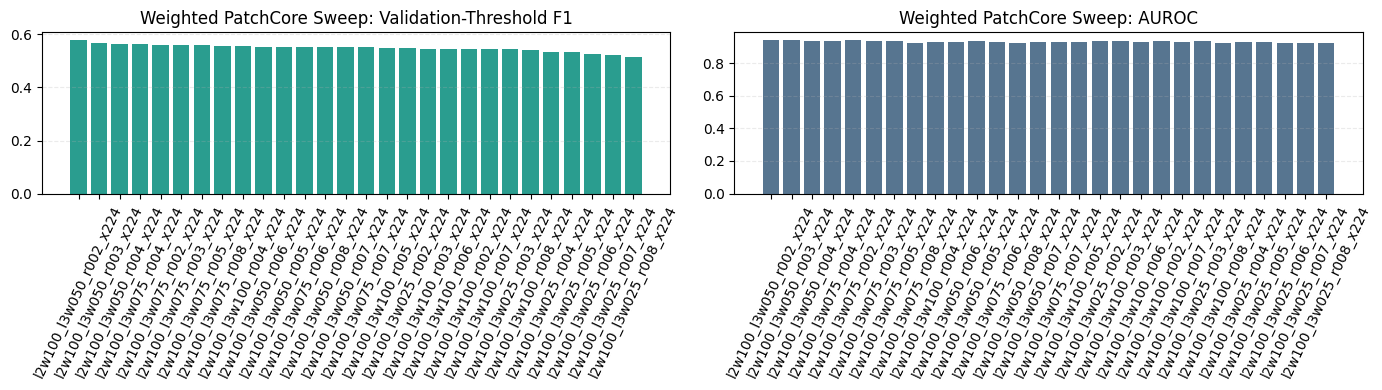

Best variant:
{
  "name": "l2w100_l3w050_r002_x224",
  "weight_name": "l2w100_l3w050",
  "layer2_weight": 1.0,
  "layer3_weight": 0.5,
  "memory_bank_size": 600000,
  "memory_subset_images": 800,
  "patches_per_image": 784,
  "feature_dim": 1536,
  "reduction": "topk_mean",
  "topk_ratio": 0.02,
  "threshold": 0.557123240828514,
  "precision": 0.44835164835164837,
  "recall": 0.816,
  "f1": 0.5787234042553191,
  "auroc": 0.9420703999999998,
  "auprc": 0.7148140202802222,
  "best_sweep_threshold": 0.5862048268318176,
  "best_sweep_precision": 0.7967914438502673,
  "best_sweep_recall": 0.596,
  "best_sweep_f1": 0.6819221967963386,
  "predicted_anomalies": 455,
  "output_dir": "/home/jovyan/DeepLearning/artifacts/x224/patchcore-wideresnet50-weighted/l2w100_l3w050_r002_x224"
}


In [13]:
if "sweep_results_df" not in globals():
    sweep_results_df, best_row = load_existing_sweep_artifacts(output_dir)

combined_results_df = sweep_results_df.copy()
combined_results_df["output_dir"] = combined_results_df["name"].map(lambda name: str((output_dir / str(name)).resolve()))

if "follow_up_results_df" in globals() and not follow_up_results_df.empty:
    follow_up_display_df = follow_up_results_df.copy()
    follow_up_display_df["output_dir"] = follow_up_display_df["name"].map(lambda name: str((output_dir / str(name)).resolve()))
    combined_results_df = (
        pd.concat([combined_results_df, follow_up_display_df], ignore_index=True)
        .sort_values(["f1", "auroc"], ascending=False)
        .reset_index(drop=True)
    )

best_row = normalize_variant_record(combined_results_df.iloc[0].to_dict(), output_dir)

display(
    combined_results_df[
        [
            "name",
            "weight_name",
            "layer2_weight",
            "layer3_weight",
            "topk_ratio",
            "precision",
            "recall",
            "f1",
            "auroc",
            "auprc",
            "best_sweep_f1",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(combined_results_df["name"], combined_results_df["f1"], color="#2a9d8f")
axes[0].set_title("Weighted PatchCore Sweep: Validation-Threshold F1")
axes[0].tick_params(axis="x", rotation=65)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")

axes[1].bar(combined_results_df["name"], combined_results_df["auroc"], color="#577590")
axes[1].set_title("Weighted PatchCore Sweep: AUROC")
axes[1].tick_params(axis="x", rotation=65)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()

print("Best variant:")
print(json.dumps(best_row, indent=2))


## Selected Variant Defect Breakdown

This cell loads the selected best weighted `layer2 + layer3` PatchCore variant and computes its defect-type recall under the deployed validation-derived threshold.


In [14]:
# DEFECT_BREAKDOWN_CELL
summary_path = output_dir / "patchcore_sweep_summary.json"
if "best_row" not in globals():
    if summary_path.exists():
        _, best_row = load_existing_sweep_artifacts(output_dir)
    else:
        raise FileNotFoundError(f"Sweep summary not found: {summary_path}. No retraining needed, but rerun the sweep summary cell first.")
else:
    best_row = normalize_variant_record(best_row, output_dir)

required_globals = ["output_dir", "test_dataset"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "No retraining needed. Rerun the notebook setup/data cells so these objects exist: "
        + ", ".join(missing_globals)
    )

best_variant_name = str(best_row["name"])
best_threshold = float(best_row["threshold"])
variant_output_dir = Path(best_row["output_dir"])
best_scores_path = variant_output_dir / "test_scores.csv"
if not best_scores_path.exists():
    raise FileNotFoundError(f"Test scores not found for best variant: {best_scores_path}")

best_scores_df = pd.read_csv(best_scores_path).reset_index(drop=True)
analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
if len(best_scores_df) != len(analysis_df):
    raise ValueError(f"Length mismatch: scores={len(best_scores_df)} metadata={len(analysis_df)}")
analysis_df["score"] = best_scores_df["score"]
analysis_df["predicted_anomaly"] = (analysis_df["score"] >= best_threshold).astype(int)

defect_breakdown_df = (
    analysis_df.loc[analysis_df["is_anomaly"] == 1]
    .groupby("defect_type")
    .agg(
        count=("defect_type", "size"),
        detected=("predicted_anomaly", "sum"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
    )
    .reset_index()
)
defect_breakdown_df["detected"] = defect_breakdown_df["detected"].astype(int)
defect_breakdown_df["missed"] = defect_breakdown_df["count"] - defect_breakdown_df["detected"]
defect_breakdown_df["recall"] = defect_breakdown_df["detected"] / defect_breakdown_df["count"]
defect_breakdown_df = defect_breakdown_df.sort_values(["recall", "count", "defect_type"], ascending=[True, False, True]).reset_index(drop=True)

display(pd.Series(best_row))
display(defect_breakdown_df)
output_path = variant_output_dir / "selected_defect_breakdown.csv"
defect_breakdown_df.to_csv(output_path, index=False)
print(f"Saved defect breakdown to {output_path}")


name                                              l2w100_l3w050_r002_x224
weight_name                                                 l2w100_l3w050
layer2_weight                                                         1.0
layer3_weight                                                         0.5
memory_bank_size                                                   600000
memory_subset_images                                                  800
patches_per_image                                                     784
feature_dim                                                          1536
reduction                                                       topk_mean
topk_ratio                                                           0.02
threshold                                                        0.557123
precision                                                        0.448352
recall                                                              0.816
f1                                    

,defect_type,count,detected,mean_score,median_score,missed,recall
0,Scratch,15,10,0.589493,0.570163,5,0.666667
1,Loc,34,24,0.592735,0.595644,10,0.705882
2,Edge-Loc,53,38,0.584717,0.587915,15,0.716981
3,Center,50,41,0.584806,0.586524,9,0.820000
4,Edge-Ring,84,77,0.596506,0.597024,7,0.916667
5,Donut,7,7,0.646886,0.637591,0,1.000000
6,Random,5,5,0.641628,0.645480,0,1.000000
7,Near-full,2,2,0.636178,0.636178,0,1.000000


Saved defect breakdown to /home/jovyan/DeepLearning/artifacts/x224/patchcore-wideresnet50-weighted/l2w100_l3w050_r002_x224/selected_defect_breakdown.csv


## Selected Variant UMAP Export

This follow-up cell reuses the selected best weighted `18E` variant, rebuilds its fitted memory bank, and exports a UMAP diagnostic without changing the reported evaluation protocol.

Notes:

- this is interpretive only; it does not change the selected threshold or the reported metrics
- if `umap-learn` is missing in your environment, install it first
- the exported files are saved under the selected variant's `evaluation/` directory


In [ ]:
# UMAP_EXPORT_CELL
try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError("Install umap-learn in the active environment before running this cell.") from exc

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

summary_path = output_dir / "patchcore_sweep_summary.json"
if "best_row" not in globals():
    if summary_path.exists():
        _, best_row = load_existing_sweep_artifacts(output_dir)
    else:
        raise FileNotFoundError(f"Sweep summary not found: {summary_path}. Rerun the sweep summary cell first.")
else:
    best_row = normalize_variant_record(best_row, output_dir)

required_globals = ["output_dir", "train_dataset", "val_dataset", "test_dataset", "device"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Rerun the notebook setup/data cells so these objects exist: " + ", ".join(missing_globals)
    )

selected_variant = {
    "name": str(best_row["name"]),
    "weight_name": str(best_row["weight_name"]),
    "layer_weights": {
        "layer2": float(best_row["layer2_weight"]),
        "layer3": float(best_row["layer3_weight"]),
    },
    "memory_bank_size": int(best_row["memory_bank_size"]),
    "reduction": str(best_row["reduction"]),
    "topk_ratio": float(best_row["topk_ratio"]),
}
variant_output_dir = Path(best_row["output_dir"])
evaluation_dir = variant_output_dir / "evaluation"
plots_dir = evaluation_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

umap_model = MultiLayerPatchCoreModel(
    image_size=IMAGE_SIZE,
    teacher_layers=TEACHER_LAYERS,
    memory_bank_size=selected_variant["memory_bank_size"],
    reduction=selected_variant["reduction"],
    topk_ratio=selected_variant["topk_ratio"],
    pretrained=PRETRAINED,
    freeze_backbone=FREEZE_BACKBONE,
    backbone_input_size=TEACHER_INPUT_SIZE,
    normalize_imagenet=NORMALIZE_IMAGENET,
    query_chunk_size=QUERY_CHUNK_SIZE,
    memory_chunk_size=MEMORY_CHUNK_SIZE,
    layer_weights=selected_variant["layer_weights"],
).to(device)

memory_subset = build_memory_subset(
    train_dataset,
    selected_variant["memory_bank_size"],
    umap_model.patches_per_image,
    SEED,
    min_images=MIN_MEMORY_IMAGES,
)
memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
umap_model.set_memory_bank(collect_memory_bank(umap_model, memory_loader, device, target_size=selected_variant["memory_bank_size"], seed=SEED))

val_loader_eval = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader_eval = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

def collect_embeddings_and_scores(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device, desc: str):
    embeddings = []
    labels = []
    scores = []
    model.eval()
    with torch.inference_mode():
        for inputs, batch_labels in tqdm(dataloader, desc=desc):
            inputs = inputs.to(device)
            patch_embeddings = model.patch_embeddings(inputs)
            image_embeddings = patch_embeddings.mean(dim=1)
            patch_distances = model.nearest_patch_distances(patch_embeddings)
            batch_scores = model.reduce_patch_distances(patch_distances)
            embeddings.append(image_embeddings.cpu().numpy())
            labels.extend(int(x) for x in batch_labels.tolist())
            scores.extend(float(x) for x in batch_scores.cpu().tolist())
    return np.concatenate(embeddings, axis=0), np.asarray(labels, dtype=np.int64), np.asarray(scores, dtype=np.float32)

val_embeddings, val_labels, val_scores = collect_embeddings_and_scores(umap_model, val_loader_eval, device, "Collect val embeddings")
test_embeddings, test_labels, test_scores = collect_embeddings_and_scores(umap_model, test_loader_eval, device, "Collect test embeddings")

val_normal_mask = val_labels == 0
val_normal_scores = val_scores[val_normal_mask]
model_threshold = float(pd.Series(val_normal_scores).quantile(THRESHOLD_QUANTILE))
original_metrics = summarize_threshold_metrics(test_labels, test_scores, model_threshold)
original_sweep_df, original_best_sweep = sweep_threshold_metrics(test_labels, test_scores)

pca = None
umap_input = val_embeddings[val_normal_mask]
if umap_input.shape[1] > 50:
    pca = PCA(n_components=min(50, umap_input.shape[0], umap_input.shape[1]), random_state=SEED)
    umap_input = pca.fit_transform(umap_input)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=SEED,
    transform_seed=SEED,
)
reducer.fit(umap_input)

def transform_features(features: np.ndarray) -> np.ndarray:
    transformed = features if pca is None else pca.transform(features)
    return reducer.transform(transformed)

val_points = transform_features(val_embeddings)
test_points = transform_features(test_embeddings)


def knn_reference_scores(reference_points: np.ndarray, query_points: np.ndarray, k: int = 15) -> np.ndarray:
    k = max(1, min(k, len(reference_points)))
    nbrs = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nbrs.fit(reference_points)
    distances, _ = nbrs.kneighbors(query_points, return_distance=True)
    return distances.mean(axis=1)


def knn_reference_scores_leave_one_out(reference_points: np.ndarray, k: int = 15) -> np.ndarray:
    k = max(1, min(k, len(reference_points) - 1 if len(reference_points) > 1 else 1))
    if len(reference_points) <= 1:
        return np.zeros(len(reference_points), dtype=np.float32)
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nbrs.fit(reference_points)
    distances, _ = nbrs.kneighbors(reference_points, return_distance=True)
    return distances[:, 1:].mean(axis=1)

val_umap_scores = knn_reference_scores_leave_one_out(val_points[val_normal_mask], k=15)
test_umap_scores = knn_reference_scores(val_points[val_normal_mask], test_points, k=15)
umap_threshold = float(pd.Series(val_umap_scores).quantile(THRESHOLD_QUANTILE))
umap_metrics = summarize_threshold_metrics(test_labels, test_umap_scores, umap_threshold)
umap_sweep_df, umap_best_sweep = sweep_threshold_metrics(test_labels, test_umap_scores)

combined_df = pd.concat(
    [
        pd.DataFrame(
            {
                "split": "val",
                "group": np.where(val_labels == 0, "val_normal", "val_anomaly"),
                "is_anomaly": val_labels.astype(int),
                "model_score": val_scores.astype(float),
                "umap1": val_points[:, 0],
                "umap2": val_points[:, 1],
            }
        ),
        pd.DataFrame(
            {
                "split": "test",
                "group": np.where(test_labels == 0, "test_normal", "test_anomaly"),
                "is_anomaly": test_labels.astype(int),
                "model_score": test_scores.astype(float),
                "umap1": test_points[:, 0],
                "umap2": test_points[:, 1],
            }
        ),
    ],
    ignore_index=True,
)
combined_df["umap_knn_score"] = np.nan
combined_df.loc[combined_df["group"] == "val_normal", "umap_knn_score"] = val_umap_scores
combined_df.loc[combined_df["split"] == "test", "umap_knn_score"] = test_umap_scores
combined_df.to_csv(evaluation_dir / "umap_points.csv", index=False)
np.save(evaluation_dir / "val_embeddings.npy", val_embeddings)
np.save(evaluation_dir / "test_embeddings.npy", test_embeddings)
np.save(evaluation_dir / "val_labels.npy", val_labels)
np.save(evaluation_dir / "test_labels.npy", test_labels)
np.save(evaluation_dir / "val_scores.npy", val_scores)
np.save(evaluation_dir / "test_scores.npy", test_scores)

plot_df = combined_df[combined_df["group"].isin(["val_normal", "test_normal", "test_anomaly"])]

plt.figure(figsize=(9, 7))
for group, color in [("val_normal", "#1f77b4"), ("test_normal", "#2ca02c"), ("test_anomaly", "#d62728")]:
    subset = plot_df[plot_df["group"] == group]
    if subset.empty:
        continue
    plt.scatter(subset["umap1"], subset["umap2"], s=10, alpha=0.55, label=group, c=color)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title(f"{selected_variant['name']}: UMAP by Split")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(plots_dir / "umap_by_split.png", dpi=220, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 7))
scatter = plt.scatter(plot_df["umap1"], plot_df["umap2"], c=plot_df["model_score"], cmap="viridis", s=10, alpha=0.65)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title(f"{selected_variant['name']}: UMAP by Model Score")
plt.colorbar(scatter, label="Model Score")
plt.tight_layout()
plt.savefig(plots_dir / "umap_by_score.png", dpi=220, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for group, color in [("test_normal", "#2ca02c"), ("test_anomaly", "#d62728")]:
    subset = plot_df[plot_df["group"] == group]
    if subset.empty:
        continue
    plt.hist(subset["model_score"], bins=50, alpha=0.55, label=group, color=color)
plt.axvline(model_threshold, color="black", linestyle="--", linewidth=1.5, label=f"threshold={model_threshold:.4f}")
plt.xlabel("Model Score")
plt.ylabel("Count")
plt.title(f"{selected_variant['name']}: Score Histogram")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(plots_dir / "score_histogram.png", dpi=220, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(original_sweep_df["threshold"], original_sweep_df["precision"], label="precision")
plt.plot(original_sweep_df["threshold"], original_sweep_df["recall"], label="recall")
plt.plot(original_sweep_df["threshold"], original_sweep_df["f1"], label="f1")
plt.axvline(model_threshold, color="black", linestyle="--", linewidth=1.5, label=f"val-95 threshold={model_threshold:.4f}")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title(f"{selected_variant['name']}: Threshold Sweep")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(plots_dir / "threshold_sweep_metrics.png", dpi=220, bbox_inches="tight")
plt.show()

umap_summary = {
    "name": selected_variant["name"],
    "weight_name": selected_variant["weight_name"],
    "layer_weights": selected_variant["layer_weights"],
    "threshold_quantile": float(THRESHOLD_QUANTILE),
    "counts": {
        "val_normal": int((val_labels == 0).sum()),
        "test_normal": int((test_labels == 0).sum()),
        "test_anomaly": int((test_labels == 1).sum()),
    },
    "umap_params": {
        "random_state": int(SEED),
        "pca_components": 50,
        "n_neighbors": 15,
        "min_dist": 0.1,
        "knn_k": 15,
    },
    "original_score": {
        "threshold": float(model_threshold),
        "metrics_at_validation_threshold": original_metrics,
        "best_threshold_sweep": original_best_sweep,
    },
    "umap_knn_score": {
        "threshold": float(umap_threshold),
        "metrics_at_validation_threshold": umap_metrics,
        "best_threshold_sweep": umap_best_sweep,
    },
}
(evaluation_dir / "umap_summary.json").write_text(json.dumps(umap_summary, indent=2), encoding="utf-8")
original_sweep_df.to_csv(evaluation_dir / "model_threshold_sweep.csv", index=False)
umap_sweep_df.to_csv(evaluation_dir / "umap_knn_threshold_sweep.csv", index=False)
display(pd.json_normalize(umap_summary, sep="."))
print(f"Saved UMAP artifacts to {evaluation_dir}")


## Alternative Narrow Follow-Up Sweep

This cell defines a smaller follow-up around the strongest `18E` region rather than rerunning the full grid.

Suggested focus:

- keep `layer2 = 1.0`
- probe `layer3` near the current winner: `0.40`, `0.50`, `0.60`, `0.75`
- probe `topk_ratio` near the current winner: `0.015`, `0.020`, `0.025`, `0.030`, `0.040`

The cell is off by default. Set `RUN_ALTERNATIVE_VARIATIONS = True` when you want to execute it.


In [ ]:
# ALTERNATIVE_VARIATIONS_CELL
RUN_ALTERNATIVE_VARIATIONS = False
FOLLOW_UP_OUTPUT_DIR = output_dir / "follow_up_local_weighted"
FOLLOW_UP_LAYER_WEIGHT_SWEEP = [
    {"name": "l2w100_l3w040", "layer_weights": {"layer2": 1.0, "layer3": 0.40}},
    {"name": "l2w100_l3w050", "layer_weights": {"layer2": 1.0, "layer3": 0.50}},
    {"name": "l2w100_l3w060", "layer_weights": {"layer2": 1.0, "layer3": 0.60}},
    {"name": "l2w100_l3w075", "layer_weights": {"layer2": 1.0, "layer3": 0.75}},
]
FOLLOW_UP_TOPK_RATIO_SWEEP = [0.015, 0.020, 0.025, 0.030, 0.040]
FOLLOW_UP_VARIANTS = [
    {
        "name": f"{weight_cfg['name']}_r{int(round(topk_ratio * 1000)):03d}_x224",
        "weight_name": weight_cfg["name"],
        "layer_weights": weight_cfg["layer_weights"],
        "memory_bank_size": MEMORY_BANK_SIZE,
        "reduction": "topk_mean",
        "topk_ratio": float(topk_ratio),
    }
    for weight_cfg in FOLLOW_UP_LAYER_WEIGHT_SWEEP
    for topk_ratio in FOLLOW_UP_TOPK_RATIO_SWEEP
]

follow_up_plan_df = pd.DataFrame(
    [
        {
            "name": variant["name"],
            "weight_name": variant["weight_name"],
            "layer2_weight": float(variant["layer_weights"]["layer2"]),
            "layer3_weight": float(variant["layer_weights"]["layer3"]),
            "topk_ratio": float(variant["topk_ratio"]),
            "memory_bank_size": int(variant["memory_bank_size"]),
        }
        for variant in FOLLOW_UP_VARIANTS
    ]
)
display(follow_up_plan_df)

if not RUN_ALTERNATIVE_VARIATIONS:
    print("Set RUN_ALTERNATIVE_VARIATIONS = True to execute this narrow follow-up sweep.")
else:
    FOLLOW_UP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    follow_up_results_path = FOLLOW_UP_OUTPUT_DIR / "patchcore_sweep_results.csv"
    follow_up_summary_path = FOLLOW_UP_OUTPUT_DIR / "patchcore_sweep_summary.json"

    grouped_variants = {}
    for variant in FOLLOW_UP_VARIANTS:
        grouped_variants.setdefault(str(variant["weight_name"]), []).append(variant)

    follow_up_rows = []
    for weight_name, variants in grouped_variants.items():
        variants = sorted(variants, key=lambda item: float(item["topk_ratio"]))
        base_variant = variants[0]
        print(f"\n=== Follow-up weight setting: {weight_name} | layer_weights={base_variant['layer_weights']} ===")

        completed_rows = []
        pending_variants = []
        for variant in variants:
            variant_output_dir = FOLLOW_UP_OUTPUT_DIR / variant["name"]
            if variant_artifact_complete(variant_output_dir):
                completed_rows.append(load_variant_row(variant_output_dir))
                print(f"  -> reusing completed variant {variant['name']}")
            else:
                pending_variants.append(variant)

        follow_up_rows.extend(completed_rows)
        if not pending_variants:
            continue

        cache_paths = cache_paths_for_weight(FOLLOW_UP_OUTPUT_DIR, weight_name)
        if weight_cache_complete(cache_paths):
            print(f"  -> loading cached patch distances for {weight_name}")
            val_patch_distances, val_labels, test_patch_distances, test_labels, cache_meta = load_weight_cache(cache_paths)
            memory_subset_images = int(cache_meta["memory_subset_images"])
            patches_per_image = int(cache_meta["patches_per_image"])
            feature_dim = int(cache_meta["feature_dim"])
        else:
            model = MultiLayerPatchCoreModel(
                image_size=IMAGE_SIZE,
                teacher_layers=TEACHER_LAYERS,
                memory_bank_size=base_variant["memory_bank_size"],
                reduction=base_variant["reduction"],
                topk_ratio=base_variant["topk_ratio"],
                pretrained=PRETRAINED,
                freeze_backbone=FREEZE_BACKBONE,
                backbone_input_size=TEACHER_INPUT_SIZE,
                normalize_imagenet=NORMALIZE_IMAGENET,
                query_chunk_size=QUERY_CHUNK_SIZE,
                memory_chunk_size=MEMORY_CHUNK_SIZE,
                layer_weights=base_variant["layer_weights"],
            ).to(device)
            memory_subset = build_memory_subset(train_dataset, base_variant["memory_bank_size"], model.patches_per_image, SEED, min_images=MIN_MEMORY_IMAGES)
            memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=base_variant["memory_bank_size"], seed=SEED))
            val_patch_distances, val_labels = collect_patch_distances(model, val_loader, device)
            test_patch_distances, test_labels = collect_patch_distances(model, test_loader, device)
            memory_subset_images = int(len(memory_subset))
            patches_per_image = int(model.patches_per_image)
            feature_dim = int(model.feature_dim)
            save_weight_cache(
                cache_paths,
                val_patch_distances,
                val_labels,
                test_patch_distances,
                test_labels,
                {
                    "weight_name": weight_name,
                    "layer_weights": base_variant["layer_weights"],
                    "memory_bank_size": int(base_variant["memory_bank_size"]),
                    "memory_subset_images": memory_subset_images,
                    "patches_per_image": patches_per_image,
                    "feature_dim": feature_dim,
                },
            )
            print(f"  -> cached patch distances for {weight_name}")

        for variant in pending_variants:
            variant_output_dir = FOLLOW_UP_OUTPUT_DIR / variant["name"]
            variant_output_dir.mkdir(parents=True, exist_ok=True)
            val_scores_df = scores_from_patch_distances(val_patch_distances, val_labels, reduction=variant["reduction"], topk_ratio=float(variant["topk_ratio"]))
            test_scores_df = scores_from_patch_distances(test_patch_distances, test_labels, reduction=variant["reduction"], topk_ratio=float(variant["topk_ratio"]))
            threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
            labels = test_scores_df["is_anomaly"].to_numpy()
            scores = test_scores_df["score"].to_numpy()
            metrics = summarize_threshold_metrics(labels, scores, threshold)
            threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
            summary = {
                "name": variant["name"],
                "weight_name": variant["weight_name"],
                "teacher_backbone": "wideresnet50_2",
                "teacher_layers": TEACHER_LAYERS,
                "layer_weights": variant["layer_weights"],
                "memory_bank_size": int(variant["memory_bank_size"]),
                "memory_subset_images": memory_subset_images,
                "patches_per_image": patches_per_image,
                "feature_dim": feature_dim,
                "reduction": variant["reduction"],
                "topk_ratio": float(variant["topk_ratio"]),
                "threshold_quantile": THRESHOLD_QUANTILE,
                "threshold": float(threshold),
                "metrics_at_validation_threshold": metrics,
                "best_threshold_sweep": {
                    "threshold": float(best_sweep["threshold"]),
                    "precision": float(best_sweep["precision"]),
                    "recall": float(best_sweep["recall"]),
                    "f1": float(best_sweep["f1"]),
                    "predicted_anomalies": float(best_sweep["predicted_anomalies"]),
                },
            }
            val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False)
            test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False)
            threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
            (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
            follow_up_rows.append(load_variant_row(variant_output_dir))
            print(f"  -> saved follow-up variant {variant['name']}")

    follow_up_results_df, follow_up_best_row = persist_sweep_results(
        FOLLOW_UP_OUTPUT_DIR,
        follow_up_results_path,
        follow_up_summary_path,
        follow_up_rows,
        FOLLOW_UP_VARIANTS,
        TEACHER_LAYERS,
    )
    display(follow_up_results_df[["name", "weight_name", "layer2_weight", "layer3_weight", "topk_ratio", "precision", "recall", "f1", "auroc", "auprc", "best_sweep_f1"]])
    print("Follow-up best variant:")
    print(json.dumps(follow_up_best_row, indent=2))
